# ![](https://ga-dash.s3.amazonaws.com/production/assets/logo-9f88ae6c9c3871690e33280fcf557f33.png) Project Capstone

## Forecasting and Optimizing Solar Power: Predictive and Reinforcement Learning Approaches

---

[README](../README.md) | **Part 1: EDA** | [Part 2: xx](02_Vectorizer.ipynb)

---

### Introduction

https://www.kaggle.com/datasets/stefancomanita/hourly-electricity-consumption-and-production

https://www.visualcrossing.com/weather/weather-data-services/Bucharest,Romania/metric/

https://thingler.io/country/Romania


<!-- def create_hourly_csv(filename):
    # Define start and end datetime
    start = "2024-01-01 00:00"
    end = "2024-03-31 23:00"
    
    # Generate date range with hourly frequency
    date_range = pd.date_range(start=start, end=end, freq='H')
    
    # Create a DataFrame
    df = pd.DataFrame({"dt": date_range})
    
    # Save to CSV
    df.to_csv(filename, index=False)
    print(f"CSV file '{filename}' created successfully!")

# Call the function
create_hourly_csv("hourly_data.csv") -->

### Import

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
weather_jan = pd.read_csv('../data/bucharest_weather_jan24.csv')
weather_feb = pd.read_csv('../data/bucharest_weather_feb24.csv')
weather_mar = pd.read_csv('../data/bucharest_weather_mar24.csv')

In [19]:
# weather_mar have 1 missing row
weather_jan.shape, weather_feb.shape, weather_mar.shape

((744, 24), (696, 24), (743, 24))

In [21]:
weather = pd.concat([weather_jan, weather_feb, weather_mar]
                    , axis = 0
                    , ignore_index = True
                   )

In [125]:
percent_zeros = (weather == 0).mean() * 100
percent_null = weather.isnull().mean() * 100
# Create the DataFrame with data type, % missing values, and % zeros
column_info = pd.DataFrame({
    'Data Type': weather.dtypes,
    '% Missing Values': percent_null,
    '% Zeros': percent_zeros
})

print(column_info)

                 Data Type  % Missing Values    % Zeros
name                object          0.000000   0.000000
datetime            object          0.000000   0.000000
temp               float64          0.000000   0.229043
feelslike          float64          0.000000   0.320660
dew                float64          0.000000   0.549702
humidity           float64          0.000000   0.000000
precip             float64          0.000000  96.930829
precipprob           int64          0.000000  96.930829
preciptype          object         96.472744   0.000000
snow               float64          0.000000  99.450298
snowdepth          float64          0.000000  87.036189
windgust           float64          0.000000   0.000000
windspeed          float64          0.000000   0.870362
winddir            float64          0.000000   0.183234
sealevelpressure   float64          0.000000   0.000000
cloudcover         float64          0.000000  11.726981
visibility         float64          0.045809   0

In [ ]:
weather.drop(columns = ['name'
                        , 'precip'
                        , 'precipprob'
                        , 'preciptype'
                        , 'snow'
                        , 'snowdepth'
                        , 'severerisk'
                        , 'conditions'
                        , 'stations'
             ])

In [119]:
weather.groupby('icon')['snowdepth'].value_counts()

icon       snowdepth
clear-day  0.00         117
           0.70           3
           1.00           1
           9.11           1
           9.30           1
                       ... 
snow       6.00           1
           7.99           1
           8.99           1
           11.16          1
           13.96          1
Name: count, Length: 154, dtype: int64

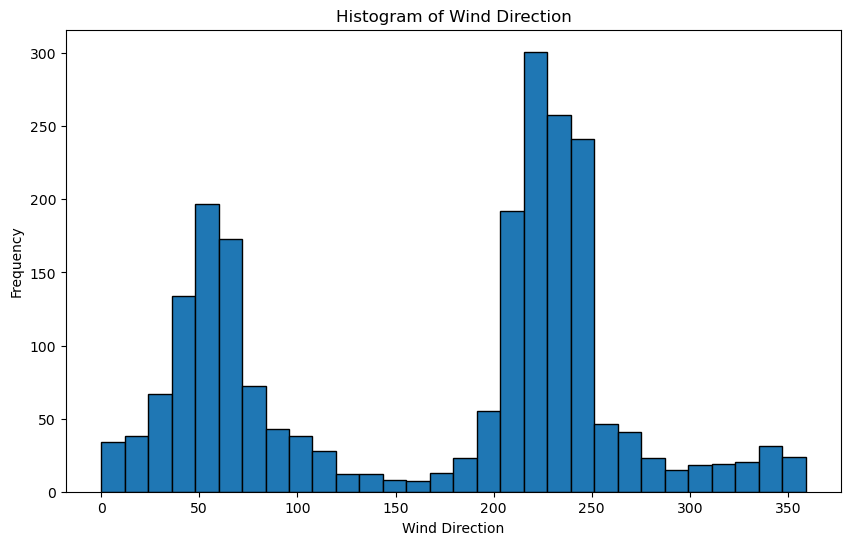

In [111]:
# Plot histogram for the 'winddir' column
plt.figure(figsize=(10, 6))
plt.hist(weather['winddir'].dropna(), bins=30, edgecolor='black')
plt.title('Histogram of Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Frequency')
plt.show()